# Otimização de Rotas Médicas  - Entrega medicamentos

## Tech Challenge Fase 2

---
### Eduardo Toshio Yonamine - 9IADT - Grupo 37 - 14/07/2026

---
# Setup e imports do projeto - medical_route_optimizer

## Mapeamento e importação das principais funcionalidades para a apresentação

In [2]:
import os
import sys
import random
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def _find_project_root() -> Path:
    env_root = os.environ.get("PROJECT_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "src" / "medical_route_optimizer").exists():
            return candidate

    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "src" / "medical_route_optimizer").exists():
            return candidate

    raise ModuleNotFoundError(
        "Não foi possível localizar a pasta src/medical_route_optimizer. "
        "Abra o notebook a partir do repositório ou defina a variável PROJECT_ROOT."
    )

PROJECT_ROOT = _find_project_root()
SRC_ROOT = PROJECT_ROOT / "src"
PACKAGE_ROOT = SRC_ROOT / "medical_route_optimizer"

for p in (SRC_ROOT, PACKAGE_ROOT):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

from data.delivery_points import get_hospital_base, get_pontos_entrega_sem_origem, PRIORIDADE_LABEL
from core.nearest_neighbor import avaliar_baseline_nn, gerar_populacao_nearest_neighbor
from core.population_helper import gerar_populacao_aleatoria
from core.genetic_algorithm import executar_algoritmo_genetico
from core.two_opt import two_opt_inversion, two_opt_vrp
from core.vrp_split import dividir_rotas_vrp, resumo_restricoes_vrp
from reports.route_report import gerar_relatorio_rota

random.seed(42)
np.random.seed(42)


---
# Características do pipeline do GA (Genetic Algorithm)

In [3]:
classificacoes = {
    "Representação": "Permutação dos pontos (hospital fixo fora do cromossomo)",
    "Inicialização": "População híbrida (Nearest Neighbor + aleatória)",
    "Fitness": "Distância + penalidade de prioridade + capacidade + autonomia",
    "Seleção": "Roleta ponderada por 1/custo + elitismo",
    "Operadores": "Crossover OX/PMX e mutações (swap/inversão)",
    "Diversidade": "Mutação adaptativa + reinicialização parcial",
    "Parada": "Paciência, convergência (std) e limite de tempo",
    "Pós-processamento": "Two-Opt Inversion",
    "VRP": "Giant Tour + VRP Split guloso"
}

for k, v in classificacoes.items():
    print(f"- {k}: {v}")

- Representação: Permutação dos pontos (hospital fixo fora do cromossomo)
- Inicialização: População híbrida (Nearest Neighbor + aleatória)
- Fitness: Distância + penalidade de prioridade + capacidade + autonomia
- Seleção: Roleta ponderada por 1/custo + elitismo
- Operadores: Crossover OX/PMX e mutações (swap/inversão)
- Diversidade: Mutação adaptativa + reinicialização parcial
- Parada: Paciência, convergência (std) e limite de tempo
- Pós-processamento: Two-Opt Inversion
- VRP: Giant Tour + VRP Split guloso


---
# Baseline do NN (Nearest Neighbor) + população híbrida (aleatória)

## Rotas NN

In [4]:
# Parâmetros de custo compartilhados entre todas as etapas do pipeline.
# Usar os mesmos valores no NN, GA e Two-Opt garante que os números
# reportados no comparativo final estejam na mesma escala de avaliação.
FATOR_PENALIDADE = 2.0   # coincide com FATOR_PENALIDADE_PRIORIDADE do GA
FATOR_PENALIDADE_CAPACIDADE = 5.0
FATOR_PENALIDADE_AUTONOMIA = 1.5
N_VEICULOS = 2
CAPACIDADE = 16
AUTONOMIA = 1400

hospital_base = get_hospital_base()
locais_entrega = get_pontos_entrega_sem_origem()

rota_nn, custo_nn = avaliar_baseline_nn(
    locais_entrega, hospital_base,
    fator_penalidade=FATOR_PENALIDADE,
    capacidade_veiculo=CAPACIDADE,
    autonomia_veiculo=AUTONOMIA,
    fator_penalidade_capacidade=FATOR_PENALIDADE_CAPACIDADE,
    fator_penalidade_autonomia=FATOR_PENALIDADE_AUTONOMIA,
)

print(f"Hospital base: {hospital_base.nome}")
print(f"Total de pontos: {len(locais_entrega)}")
print(f"Custo baseline NN: {custo_nn:.2f}")

Hospital base: Hospital Base
Total de pontos: 14
Custo baseline NN: 1542.06


## População híbrida

In [5]:
TAMANHO_POP = 120
PROPORCAO_NN = 0.15

n_nn = max(1, int(TAMANHO_POP * PROPORCAO_NN))
n_rand = TAMANHO_POP - n_nn

pop_nn = gerar_populacao_nearest_neighbor(locais_entrega, hospital_base, n_nn)
pop_rand = gerar_populacao_aleatoria(locais_entrega, n_rand)
pop_inicial = pop_nn + pop_rand

print(f"População total: {len(pop_inicial)}")
print(f" - NN: {n_nn}")
print(f" - Aleatória: {n_rand}")

População total: 120
 - NN: 18
 - Aleatória: 102


---
# Execução do GA (Genetic Algorithm)

In [6]:
melhor_rota_ga, custo_ga, historico_melhor, historico_media = executar_algoritmo_genetico(
    locais_entrega=locais_entrega,
    hospital_base=hospital_base,
    populacao_inicial=pop_inicial,
    probabilidade_mutacao=0.30,
    paciencia=40,
    limite_tempo=30,
    fator_penalidade=FATOR_PENALIDADE,
    fator_penalidade_capacidade=FATOR_PENALIDADE_CAPACIDADE,
    fator_penalidade_autonomia=FATOR_PENALIDADE_AUTONOMIA,
    capacidade_veiculo=CAPACIDADE,
    autonomia_veiculo=AUTONOMIA,
    verbose=False,
    animacao=None
)

print(f"Custo GA: {custo_ga:.2f}")


⏹  Parada antecipada na geração 51: limite de tempo atingido (30s).
Custo GA: 1323.07


---
# Refinamento com Two Opt 

In [7]:
melhor_rota_final, custo_final = two_opt_inversion(
    melhor_rota_ga,
    hospital_base,
    fator_penalidade=FATOR_PENALIDADE,
    capacidade_veiculo=CAPACIDADE,
    autonomia_veiculo=AUTONOMIA,
    fator_penalidade_capacidade=FATOR_PENALIDADE_CAPACIDADE,
    fator_penalidade_autonomia=FATOR_PENALIDADE_AUTONOMIA,
    verbose=False
)

print(f"Custo após Two-Opt: {custo_final:.2f}")
if custo_ga > 0:
    ganho_two_opt = (custo_ga - custo_final) / custo_ga * 100
    print(f"Ganho Two-Opt: {ganho_two_opt:.2f}%")

Custo após Two-Opt: 1466.72
Ganho Two-Opt: -10.86%


---
# Fitness - VRP SPLIT 

In [8]:
# N_VEICULOS, CAPACIDADE, AUTONOMIA já definidos na célula de Baseline NN

rotas_vrp = dividir_rotas_vrp(
    giant_tour=melhor_rota_final,
    hospital_base=hospital_base,
    capacidade_veiculo=CAPACIDADE,
    autonomia_veiculo=AUTONOMIA,
    n_veiculos=N_VEICULOS
)

resumo = resumo_restricoes_vrp(
    rotas_vrp=rotas_vrp,
    hospital_base=hospital_base,
    capacidade_veiculo=CAPACIDADE,
    autonomia_veiculo=AUTONOMIA
)

for v in resumo:
    print(f"\nVeículo {v['veiculo']}")
    print(f"  Pontos: {v['n_pontos']}")
    print(f"  Carga: {v['peso_total']} / {v['capacidade_veiculo']} | OK={v['capacidade_ok']}")
    print(f"  Distância: {v['distancia_pixels']} / {v['autonomia_veiculo']} | OK={v['autonomia_ok']}")


Veículo 1
  Pontos: 8
  Carga: 14.5 / 16 | OK=True
  Distância: 953.71 / 1400 | OK=True

Veículo 2
  Pontos: 6
  Carga: 17.0 / 16 | OK=False
  Distância: 919.21 / 1400 | OK=True


---
# Comparativo Final 

In [9]:
print("=== COMPARATIVO ===")
print(f"Baseline NN      : {custo_nn:.2f}")
print(f"GA               : {custo_ga:.2f}")
print(f"GA + Two-Opt     : {custo_final:.2f}")

ganho_vs_nn = ((custo_nn - custo_final) / custo_nn * 100) if custo_nn > 0 else 0
print(f"Economia vs NN   : {ganho_vs_nn:.2f}%")

=== COMPARATIVO ===
Baseline NN      : 1542.06
GA               : 1323.07
GA + Two-Opt     : 1466.72
Economia vs NN   : 4.89%


---
# Gráfico de convergência

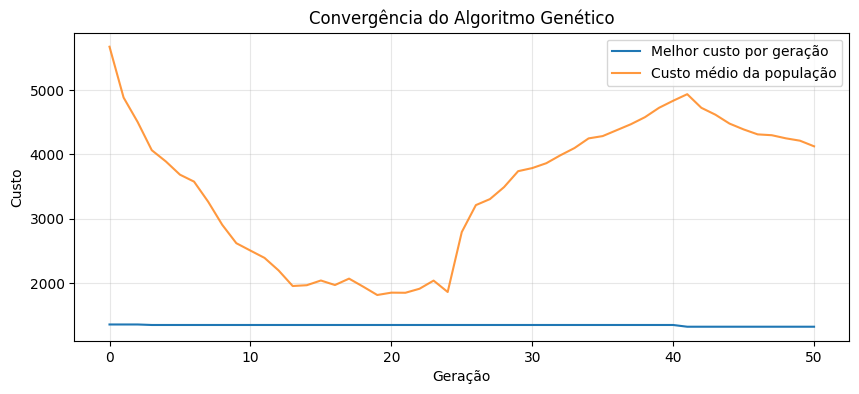

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(historico_melhor, label="Melhor custo por geração")
plt.plot(historico_media, label="Custo médio da população", alpha=0.8)
plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Geração")
plt.ylabel("Custo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Gerar o relatorio em formato JSON

In [11]:
relatorio = gerar_relatorio_rota(
    rota_otimizada=melhor_rota_final,
    hospital_base=hospital_base,
    custo_otimizado=custo_final,
    historico_custos=historico_melhor,
    rota_baseline_nn=rota_nn,
    custo_baseline_nn=custo_nn,
    rotas_vrp=rotas_vrp,
    resumo_vrp=resumo
)

output_json = f"{PROJECT_ROOT}/src/medical_route_optimizer/relatorio_demo_notebook.json"

with open(output_json, "w", encoding="utf-8") as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)

print(f"Relatório salvo em: {output_json}")

Relatório salvo em: C:\Fiap_Pos_9AIDT_Fase_02_Otimizacao_Rotas_Medicas/src/medical_route_optimizer/relatorio_demo_notebook.json
